In [47]:
import csv

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

# Specify each path

In [48]:
dataset = 'model/keypoint_classifier/keypoint.csv'
model_save_path = 'model/keypoint_classifier/keypoint_classifier.hdf5'
tflite_save_path = 'model/keypoint_classifier/keypoint_classifier.tflite'

# Set number of classes

In [49]:
NUM_CLASSES = 9

# Dataset reading

In [50]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (21 * 2) + 1)))

In [51]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.75, random_state=RANDOM_SEED)

# Model building

In [53]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((21 * 2, )),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(20, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

In [54]:
model.summary()  # tf.keras.utils.plot_model(model, show_shapes=True)

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dropout_4 (Dropout)         (None, 42)                0         
                                                                 
 dense_6 (Dense)             (None, 20)                860       
                                                                 
 dropout_5 (Dropout)         (None, 20)                0         
                                                                 
 dense_7 (Dense)             (None, 10)                210       
                                                                 
 dense_8 (Dense)             (None, 9)                 99        
                                                                 
Total params: 1169 (4.57 KB)
Trainable params: 1169 (4.57 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [55]:
# Model checkpoint callback
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False)
# Callback for early stopping
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [56]:
# Model compilation
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model training

In [57]:
model.fit(
    X_train,
    y_train,
    epochs=1500,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback]
)

Epoch 1/1500
71/71 [==============================] - ETA: 0s - loss: 2.1786 - accuracy: 0.1650
Epoch 1: saving model to model/keypoint_classifier/keypoint_classifier.hdf5
71/71 [==============================] - 1s 6ms/step - loss: 2.1786 - accuracy: 0.1650 - val_loss: 2.1115 - val_accuracy: 0.2452
Epoch 2/1500
50/71 [====================>.........] - ETA: 0s - loss: 2.0871 - accuracy: 0.2138

/home/mehregan/smart_class/lib64/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


65/71 [==========================>...] - ETA: 0s - loss: 2.0789 - accuracy: 0.2184
Epoch 2: saving model to model/keypoint_classifier/keypoint_classifier.hdf5
71/71 [==============================] - 0s 5ms/step - loss: 2.0773 - accuracy: 0.2183 - val_loss: 2.0060 - val_accuracy: 0.2940
Epoch 3/1500
70/71 [============================>.] - ETA: 0s - loss: 1.9846 - accuracy: 0.2599
Epoch 3: saving model to model/keypoint_classifier/keypoint_classifier.hdf5
71/71 [==============================] - 0s 6ms/step - loss: 1.9847 - accuracy: 0.2600 - val_loss: 1.8910 - val_accuracy: 0.3050
Epoch 4/1500
51/71 [====================>.........] - ETA: 0s - loss: 1.9176 - accuracy: 0.2794
Epoch 4: saving model to model/keypoint_classifier/keypoint_classifier.hdf5
71/71 [==============================] - 0s 3ms/step - loss: 1.9083 - accuracy: 0.2864 - val_loss: 1.7848 - val_accuracy: 0.3575
Epoch 5/1500
57/71 [=======================>......] - ETA: 0s - loss: 1.8322 - accuracy: 0.3083
Epoch 5: savin

In [58]:
# Model evaluation
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)

24/24 [==============================] - 0s 4ms/step - loss: 0.6695 - accuracy: 0.8333


In [59]:
# Loading the saved model
model = tf.keras.models.load_model(model_save_path)

In [60]:
# Inference test
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 [==============================] - 0s 41ms/step
[0.31738153 0.05913177 0.00101739 0.14334749 0.08367501 0.37967363
 0.0128624  0.00206668 0.00084407]
5


# Confusion matrix

94/94 [==============================] - 0s 1ms/step


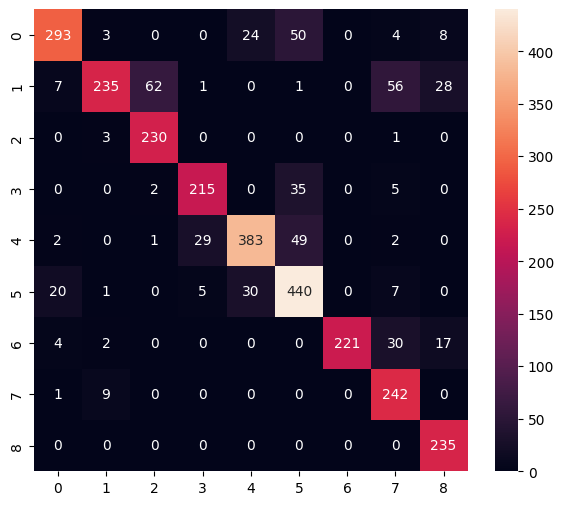

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.77      0.83       382
           1       0.93      0.60      0.73       390
           2       0.78      0.98      0.87       234
           3       0.86      0.84      0.85       257
           4       0.88      0.82      0.85       466
           5       0.77      0.87      0.82       503
           6       1.00      0.81      0.89       274
           7       0.70      0.96      0.81       252
           8       0.82      1.00      0.90       235

    accuracy                           0.83      2993
   macro avg       0.85      0.85      0.84      2993
weighted avg       0.85      0.83      0.83      2993



In [61]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
 
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)

# Convert to model for Tensorflow-Lite

In [62]:
# Save as a model dedicated to inference
model.save(model_save_path, include_optimizer=False)

/home/mehregan/smart_class/lib64/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [63]:
# Transform model (quantization)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

INFO:tensorflow:Assets written to: /tmp/tmp_1tt6416/assets


INFO:tensorflow:Assets written to: /tmp/tmp_1tt6416/assets
2026-01-03 20:12:21.802089: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
2026-01-03 20:12:21.802119: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-01-03 20:12:21.802250: I tensorflow/cc/saved_model/reader.cc:45] Reading SavedModel from: /tmp/tmp_1tt6416
2026-01-03 20:12:21.802760: I tensorflow/cc/saved_model/reader.cc:91] Reading meta graph with tags { serve }
2026-01-03 20:12:21.802770: I tensorflow/cc/saved_model/reader.cc:132] Reading SavedModel debug info (if present) from: /tmp/tmp_1tt6416
2026-01-03 20:12:21.804664: I tensorflow/cc/saved_model/loader.cc:231] Restoring SavedModel bundle.
2026-01-03 20:12:21.826129: I tensorflow/cc/saved_model/loader.cc:215] Running initialization op on SavedModel bundle at path: /tmp/tmp_1tt6416
2026-01-03 20:12:21.832279: I tensorflow/cc/saved_model/loader.cc:314] SavedModel

6808

# Inference test

In [64]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

In [65]:
# Get I / O tensor
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [66]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [67]:
%%time
# Inference implementation
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

CPU times: user 0 ns, sys: 271 μs, total: 271 μs
Wall time: 279 μs


In [68]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))

[0.31738147 0.05913178 0.0010174  0.14334752 0.08367503 0.37967363
 0.0128624  0.00206668 0.00084407]
5
